### Desired Outcome

###### The goal is to analyse dilievery operations,identify bottlenecks and build a predictive system to reduce delays, optimize shipping decisions and improve overall profitability and efficiency

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from warnings import filterwarnings
filterwarnings('ignore')

In [3]:
# professional color theme
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
viridis_colors=cm.viridis(np.linspace(0,1,5))
primary_color=viridis_colors[0]
secondary_color=viridis_colors[1]
accent_color=viridis_colors[2]
danger_color='#800000'
neutral_color=viridis_colors[4]
custom_palette=viridis_colors

In [4]:
df=pd.read_csv('dataset/DataCoSupplyChainDataset.csv',encoding='latin-1')
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

### Exploratory Data Analysis(EDA)

In [5]:
print(f'rows,cols :{df.shape}')
print(f'colums:{df.columns.tolist()}')
print(f'no of duplicates:{df.duplicated().sum()}')
print(df.isna().sum().sort_values(ascending=False).head(5))

rows,cols :(180519, 53)
colums:['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Product St

In [6]:
columns_to_drop=[
    'Product Description','Product Image', 'Customer Email', 'Customer Password',
    'Customer Fname', 'Customer Lname', 'Customer Street', 'Customer Zipcode',
    'Order Zipcode', 'Longitude', 'Latitude', 'Order Item Cardprod Id',
    'Order Item Id', 'Order Item Discount', 'Order Item Discount Rate',
    'Order Item Product Price', 'Order Item Quantity', 'Order Item Total',
    'Category Id', 'Department Id', 'Order Id', 'Order Customer Id',
    'Customer Id', 'Product Card Id', 'Product Category Id', 'Benefit per order',
    'Product Status', 'Customer City', 'Order City', 'Order Country',
    'Order State', 'Customer State', 'Market'
]
df=df.drop(columns=columns_to_drop)
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer Country', 'Customer Segment',
       'Department Name', 'order date (DateOrders)', 'Order Item Profit Ratio',
       'Sales', 'Order Profit Per Order', 'Order Region', 'Order Status',
       'Product Name', 'Product Price', 'shipping date (DateOrders)',
       'Shipping Mode'],
      dtype='str')

In [7]:
df[df['Delivery Status']!='Shipping canceled']

,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Segment,Department Name,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Order Region,Order Status,Product Name,Product Price,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,Consumer,Fitness,1/31/2018 22:56,0.29,327.750000,91.250000,Southeast Asia,COMPLETE,Smart watch,327.750000,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Consumer,Fitness,1/13/2018 12:27,-0.80,327.750000,-249.089996,South Asia,PENDING,Smart watch,327.750000,1/18/2018 12:27,Standard Class
2,CASH,4,4,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Consumer,Fitness,1/13/2018 12:06,-0.80,327.750000,-247.779999,South Asia,CLOSED,Smart watch,327.750000,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,Home Office,Fitness,1/13/2018 11:45,0.08,327.750000,22.860001,Oceania,COMPLETE,Smart watch,327.750000,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,298.250000,Advance shipping,0,Sporting Goods,Puerto Rico,Corporate,Fitness,1/13/2018 11:24,0.45,327.750000,134.210007,Oceania,PENDING_PAYMENT,Smart watch,327.750000,1/15/2018 11:24,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,399.980011,Shipping on time,0,Fishing,EE. UU.,Home Office,Fan Shop,1/16/2016 3:40,0.10,399.980011,40.000000,Eastern Asia,CLOSED,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,1/20/2016 3:40,Standard Class
180515,DEBIT,3,2,395.980011,Late delivery,1,Fishing,EE. UU.,Corporate,Fan Shop,1/16/2016 1:34,-1.55,399.980011,-613.770019,Eastern Asia,COMPLETE,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,1/19/2016 1:34,Second Class
180516,TRANSFER,5,4,391.980011,Late delivery,1,Fishing,EE. UU.,Corporate,Fan Shop,1/15/2016 21:00,0.36,399.980011,141.110001,Oceania,PENDING,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,1/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,387.980011,Advance shipping,0,Fishing,Puerto Rico,Consumer,Fan Shop,1/15/2016 20:18,0.48,399.980011,186.229996,Oceania,PENDING_PAYMENT,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,1/18/2016 20:18,Standard Class


In [8]:
for c in ['order date (DateOrders)','shipping date (DateOrders)']:
    df[c]=pd.to_datetime(df[c],errors='coerce',dayfirst=False)

print(f'rows/cols:{df.shape}')
print(f'{df.isna().sum().sort_values(ascending=False).head(5)}')

rows/cols:(180519, 20)
Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Sales per customer               0
Delivery Status                  0
dtype: int64


In [9]:
# checking categorical data
for col in df.columns:
    if df[col].nunique() <10:
        print(f'{col} value count')
        print(f'{df[col].value_counts()}')


Type value count
Type
DEBIT       69295
TRANSFER    49883
PAYMENT     41725
CASH        19616
Name: count, dtype: int64
Days for shipping (real) value count
Days for shipping (real)
2    56618
3    28765
6    28723
4    28513
5    28163
0     5080
1     4657
Name: count, dtype: int64
Days for shipment (scheduled) value count
Days for shipment (scheduled)
4    107752
2     35216
1     27814
0      9737
Name: count, dtype: int64
Delivery Status value count
Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64
Late_delivery_risk value count
Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64
Customer Country value count
Customer Country
EE. UU.        111146
Puerto Rico     69373
Name: count, dtype: int64
Customer Segment value count
Customer Segment
Consumer       93504
Corporate      54789
Home Office    32226
Name: count, dtype: int64
Order Status value count
Order Status
COMP

In [17]:
df['Order Processing Time']=(df['shipping date (DateOrders)']-
                             df['order date (DateOrders)']).dt.days
df['delay']=df['Order Processing Time']-df['Days for shipment (scheduled)']
df['Is_Delayed']=df['delay']>0
df['order_month']=df['order date (DateOrders)'].dt.month
df['order_day']=df['order date (DateOrders)'].dt.day_name()
df['order_hour']=df['order date (DateOrders)'].dt.hour
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Late_delivery_risk,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Product Price,shipping date (DateOrders),Order Processing Time,delay,order_month,order_hour
count,180519.000000,180519.000000,180519.000000,180519.000000,180519,180519.000000,180519.000000,180519.000000,180519.000000,180519,180519.000000,180519.000000,180519.000000,180519.000000
mean,3.497654,2.931847,183.107609,0.548291,2016-06-12 17:47:04.669868,0.120647,203.772096,21.974989,141.232550,2016-06-16 05:45:23.202433,3.471856,0.540010,6.235449,11.483689
min,0.000000,0.000000,7.490000,0.000000,2015-01-01 00:00:00,-2.750000,9.990000,-4274.979980,9.990000,2015-01-03 00:00:00,0.000000,-2.000000,1.000000,0.000000
25%,2.000000,2.000000,104.379997,0.000000,2015-09-21 13:49:00,0.080000,119.980003,7.000000,50.000000,2015-09-25 06:59:00,2.000000,0.000000,3.000000,5.000000
50%,3.000000,4.000000,163.990005,1.000000,2016-06-11 13:06:00,0.270000,199.919998,31.520000,59.990002,2016-06-15 08:32:00,3.000000,1.000000,6.000000,11.000000
75%,5.000000,4.000000,247.399994,1.000000,2017-03-01 08:42:00,0.360000,299.950012,64.800003,199.990005,2017-03-04 21:29:00,5.000000,1.000000,9.000000,17.000000
max,6.000000,4.000000,1939.989990,1.000000,2018-01-31 23:38:00,0.500000,1999.989990,911.799988,1999.989990,2018-02-06 22:14:00,6.000000,4.000000,12.000000,23.000000
std,1.623722,1.374449,120.043670,0.497664,NaN,0.466796,132.273077,104.433526,139.732492,NaN,1.670471,1.491881,3.403571,6.923006


In [18]:
df['Is_Delayed'].value_counts()

Is_Delayed
True     98743
False    81776
Name: count, dtype: int64

In [25]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer Country', 'Customer Segment',
       'Department Name', 'order date (DateOrders)', 'Order Item Profit Ratio',
       'Sales', 'Order Profit Per Order', 'Order Region', 'Order Status',
       'Product Name', 'Product Price', 'shipping date (DateOrders)',
       'Shipping Mode', 'Order Processing Time', 'delay', 'Is_Delayed',
       'order_month', 'order_day', 'order_hour'],
      dtype='str')

In [27]:
df['Order Profit Per Order']>0

0          True
1         False
2         False
3          True
4          True
          ...  
180514     True
180515    False
180516     True
180517     True
180518     True
Name: Order Profit Per Order, Length: 180519, dtype: bool

In [32]:
df['Profitability_flag']=np.where(df['Order Profit Per Order']>0,'Profit',
                                   (np.where(df['Order Profit Per Order']<0,'Loss','Break-even')))
df['Profitability_flag'].value_counts()

Profitability_flag
Profit        145558
Loss           33784
Break-even      1177
Name: count, dtype: int64

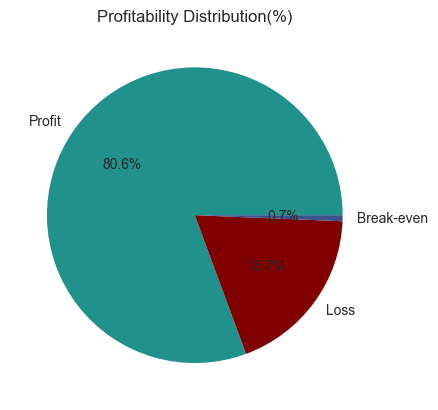

In [35]:
profit_counts=df['Profitability_flag'].value_counts(normalize=True)*100
profit_counts.plot(kind='pie',autopct='%1.1f%%',colors=[accent_color,danger_color,secondary_color])
plt.ylabel('')
plt.title('Profitability Distribution(%)')
plt.show()